# ETF-Rotation · Original research notebook

![Strategy schematic](../assets/teaser.png)

[Project README](../README.md) · [Local reproduction](../docs/REPRODUCE.md) · [New Quickstart](../Quickstart.ipynb)

> Original research code and saved outputs follow. Computational cells and execution counts are retained. Original reports are separate from this verification; read the data and dependency requirements before execution.


In [9]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

import pandas as pd
import importlib

# 1️⃣ reload modules
import data.indicators as ind
import data.data_loader as dl
import portfolio.portfolio as pf
import strategy.single_factor_strategy as st
import strategy.single_factor_full_strategy as st_full
import strategy.single_factor_full_stploss_strategy as st_stp
import strategy.single_factor_abs_stp_strategy as abs_stp
import engine.instant_engine as eng1
import engine.delay_engine as eng2
import engine.instant_full_engine as eng3
import engine.delay_full_engine as eng4
import analysis.plot_analysis as ana

importlib.reload(ind)
importlib.reload(dl)
importlib.reload(pf)
importlib.reload(st)
importlib.reload(eng1)
importlib.reload(eng2)
importlib.reload(eng3)
importlib.reload(eng4)
importlib.reload(st_full)
importlib.reload(st_stp)
importlib.reload(abs_stp)
importlib.reload(ana)

# 2. Re-import ALL classes (essential)
from data.indicators import pct_change, trend_score, rsrs, rsrs_std, trend_score_avg_price
from data.indicators import momentum_open, momentum_close, momentum_avg, trend_score_riskoff
from data.indicators import sharpe_momentum
from data.data_loader import load_etf_data

from portfolio.portfolio import Portfolio

from strategy.single_factor_strategy import SingleFactorStrategy
from strategy.single_factor_full_strategy import SingleFactorFullStrategy
from strategy.single_factor_full_stploss_strategy import SingleFactorFullStpLossStrategy
from strategy.single_factor_abs_stp_strategy import SingleFactorAbsStpStrategy

from engine.instant_full_engine import InstantFullEngine
from engine.delay_full_engine import DelayFullEngine

In [10]:
import math
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from analysis.plot_analysis import performance_metrics

# =========================
# 1. Load data
# =========================
FILE_PATH_ETF = "data/datas/ETF日频数据/etf_panel.pkl"
df_etf = load_etf_data(FILE_PATH_ETF)

# =========================
# 2. All factors
# =========================
factor_configs = {
    "trend_score": lambda: trend_score(df_etf),
    "momentum_close": lambda: momentum_close(df_etf, win_length=20),
    "momentum_open": lambda: momentum_open(df_etf, win_length=20),
    "momentum_avg": lambda: momentum_avg(df_etf, win_length=20),
    "trend_score_avg_price": lambda: trend_score_avg_price(df_etf, window=25),
}

# =========================
# 3. Base parameters
# =========================
cash = 1_000_000

# =========================
# 4. Buy & Hold curve
# =========================
buyhold_curves = {}

for etf_name, df in df_etf.items():

    df = df.sort_index()

    close = df["收盘价"]

    buyhold_equity = cash * close / close.iloc[0]

    buyhold_curves[etf_name] = pd.DataFrame({
        "timestamp": close.index,
        "equity": buyhold_equity.values
    })

# =========================
# 5. Create the main figure
# =========================
n_factor = len(factor_configs)
n_cols = 2
n_rows = math.ceil(n_factor / n_cols)

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=list(factor_configs.keys()),
    horizontal_spacing=0.08,
    vertical_spacing=0.08
)

# =========================
# 6. Backtest
# =========================
results = {}
metrics_list = []

for i, (name, factor_func) in enumerate(
        factor_configs.items(),
        start=1
):

    print(f"\n================ Running: {name} ================")

    factor_df = factor_func()

    portfolio = Portfolio(
        cash=cash,
        etf_cost_rate=0.00005,
        etf_slippage=0.0005,
        etf_min_cost=0.0
    )

    strategy = SingleFactorFullStrategy(
        factor_df=factor_df
    )

    engine = DelayFullEngine(
        data=df_etf,
        strategy=strategy,
        portfolio=portfolio,
        start="2015-01-01",
        end="2026-05-31"
    )

    result = engine.run()

    results[name] = result

    # =========================
    # Save metrics
    # =========================
    metrics = performance_metrics(result)
    metrics["factor"] = name
    metrics_list.append(metrics)

    # =========================
    # Current subplot location
    # =========================
    row = (i - 1) // n_cols + 1
    col = (i - 1) % n_cols + 1

    # =========================
    # Plot Buy & Hold
    # =========================
    for etf_name, bh in buyhold_curves.items():

        fig.add_trace(
            go.Scatter(
                x=bh["timestamp"],
                y=bh["equity"],
                mode="lines",
                name=etf_name,
                line=dict(
                    width=1,
                    dash="dot"
                ),
                opacity=0.7,
                showlegend=(i == 1),
                hovertemplate=
                f"<b>{etf_name}</b><br>"
                "日期=%{x}<br>"
                "净值=%{y:,.2f}<extra></extra>"
            ),
            row=row,
            col=col
        )

    # =========================
    # Factor strategy NAV
    # =========================
    equity = result.copy()

    if isinstance(equity.index, pd.DatetimeIndex):
        x = equity.index
    else:
        x = equity["timestamp"]

    y = equity["equity"]

    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode="lines",
            name="Factor Strategy",
            line=dict(width=3),
            showlegend=(i == 1),
            hovertemplate=
            f"<b>{name}</b><br>"
            "日期=%{x}<br>"
            "净值=%{y:,.2f}<extra></extra>"
        ),
        row=row,
        col=col
    )

# =========================
# 7. Axes
# =========================
for r in range(1, n_rows + 1):
    for c in range(1, n_cols + 1):

        fig.update_xaxes(
            title_text="Date",
            row=r,
            col=c
        )

        fig.update_yaxes(
            title_text="Portfolio Value",
            row=r,
            col=c
        )

# =========================
# 8. Chart layout
# =========================
fig.update_layout(
    title="Factor Strategy vs ETF Buy & Hold",
    height=450 * n_rows,
    width=1600,
    hovermode="x unified",
    showlegend=True
)

fig.show()

# =========================
# 9. Metrics table
# =========================
metrics_df = pd.DataFrame(metrics_list)

cols = ["factor"] + [
    c for c in metrics_df.columns
    if c != "factor"
]

metrics_df = metrics_df[cols]

pd.set_option("display.max_columns", None)

print("\n================ Metrics Table ================")
print(metrics_df)

# =========================
# 10. CAGR bar chart
# =========================
fig_bar = go.Figure()

fig_bar.add_trace(
    go.Bar(
        x=metrics_df["factor"],
        y=metrics_df["CAGR"]
    )
)

fig_bar.update_layout(
    title="CAGR Comparison",
    xaxis_title="Factor",
    yaxis_title="CAGR"
)

fig_bar.show()

# =========================
# 11. Save metrics
# =========================
"""
metrics_df.to_csv(
    "factor_backtest_metrics.csv",
    index=False
)

print("\nSaved:")
print("factor_backtest_metrics.csv")
"""


================ Running: trend_score ================
2015-01-05 00:00:00
Factor data is missing today
2015-01-06 00:00:00
Factor data is missing today
2015-01-07 00:00:00
Factor data is missing today
2015-01-08 00:00:00
Factor data is missing today
2015-01-09 00:00:00
Factor data is missing today
2015-01-12 00:00:00
Factor data is missing today
2015-01-13 00:00:00
Factor data is missing today
2015-01-14 00:00:00
Factor data is missing today
2015-01-15 00:00:00
Factor data is missing today
2015-01-16 00:00:00
Factor data is missing today
2015-01-19 00:00:00
Factor data is missing today
2015-01-20 00:00:00
Factor data is missing today
2015-01-21 00:00:00
Factor data is missing today
2015-01-22 00:00:00
Factor data is missing today
2015-01-23 00:00:00
Factor data is missing today
2015-01-26 00:00:00
Factor data is missing today
2015-01-27 00:00:00
Factor data is missing today
2015-01-28 00:00:00
Factor data is missing today
2015-01-29 00:00:00
Factor data is missing today
2015-01-30 00


================ Metrics Table ================
                  factor      CAGR  Volatility    Sharpe  Max Drawdown  \
0            trend_score  0.333084    0.260910  1.274947     -0.307185   
1         momentum_close  0.321154    0.264051  1.226536     -0.277680   
2          momentum_open  0.296083    0.270209  1.131000     -0.285016   
3           momentum_avg  0.311520    0.265601  1.192261     -0.318985   
4  trend_score_avg_price  0.300652    0.251932  1.210558     -0.307182   

     Calmar  
0  1.084310  
1  1.156564  
2  1.038828  
3  0.976598  
4  0.978741  


'\nmetrics_df.to_csv(\n    "factor_backtest_metrics.csv",\n    index=False\n)\n\nprint("\nSaved:")\nprint("factor_backtest_metrics.csv")\n'


================ Running: trend_score ================
2015-01-05 00:00:00
Factor data is missing today
2015-01-06 00:00:00
Factor data is missing today
2015-01-07 00:00:00
Factor data is missing today
2015-01-08 00:00:00
Factor data is missing today
2015-01-09 00:00:00
Factor data is missing today
2015-01-12 00:00:00
Factor data is missing today
2015-01-13 00:00:00
Factor data is missing today
2015-01-14 00:00:00
Factor data is missing today
2015-01-15 00:00:00
Factor data is missing today
2015-01-16 00:00:00
Factor data is missing today
2015-01-19 00:00:00
Factor data is missing today
2015-01-20 00:00:00
Factor data is missing today
2015-01-21 00:00:00
Factor data is missing today
2015-01-22 00:00:00
Factor data is missing today
2015-01-23 00:00:00
Factor data is missing today
2015-01-26 00:00:00
Factor data is missing today
2015-01-27 00:00:00
Factor data is missing today
2015-01-28 00:00:00
Factor data is missing today
2015-01-29 00:00:00
Factor data is missing today
2015-01-30 00

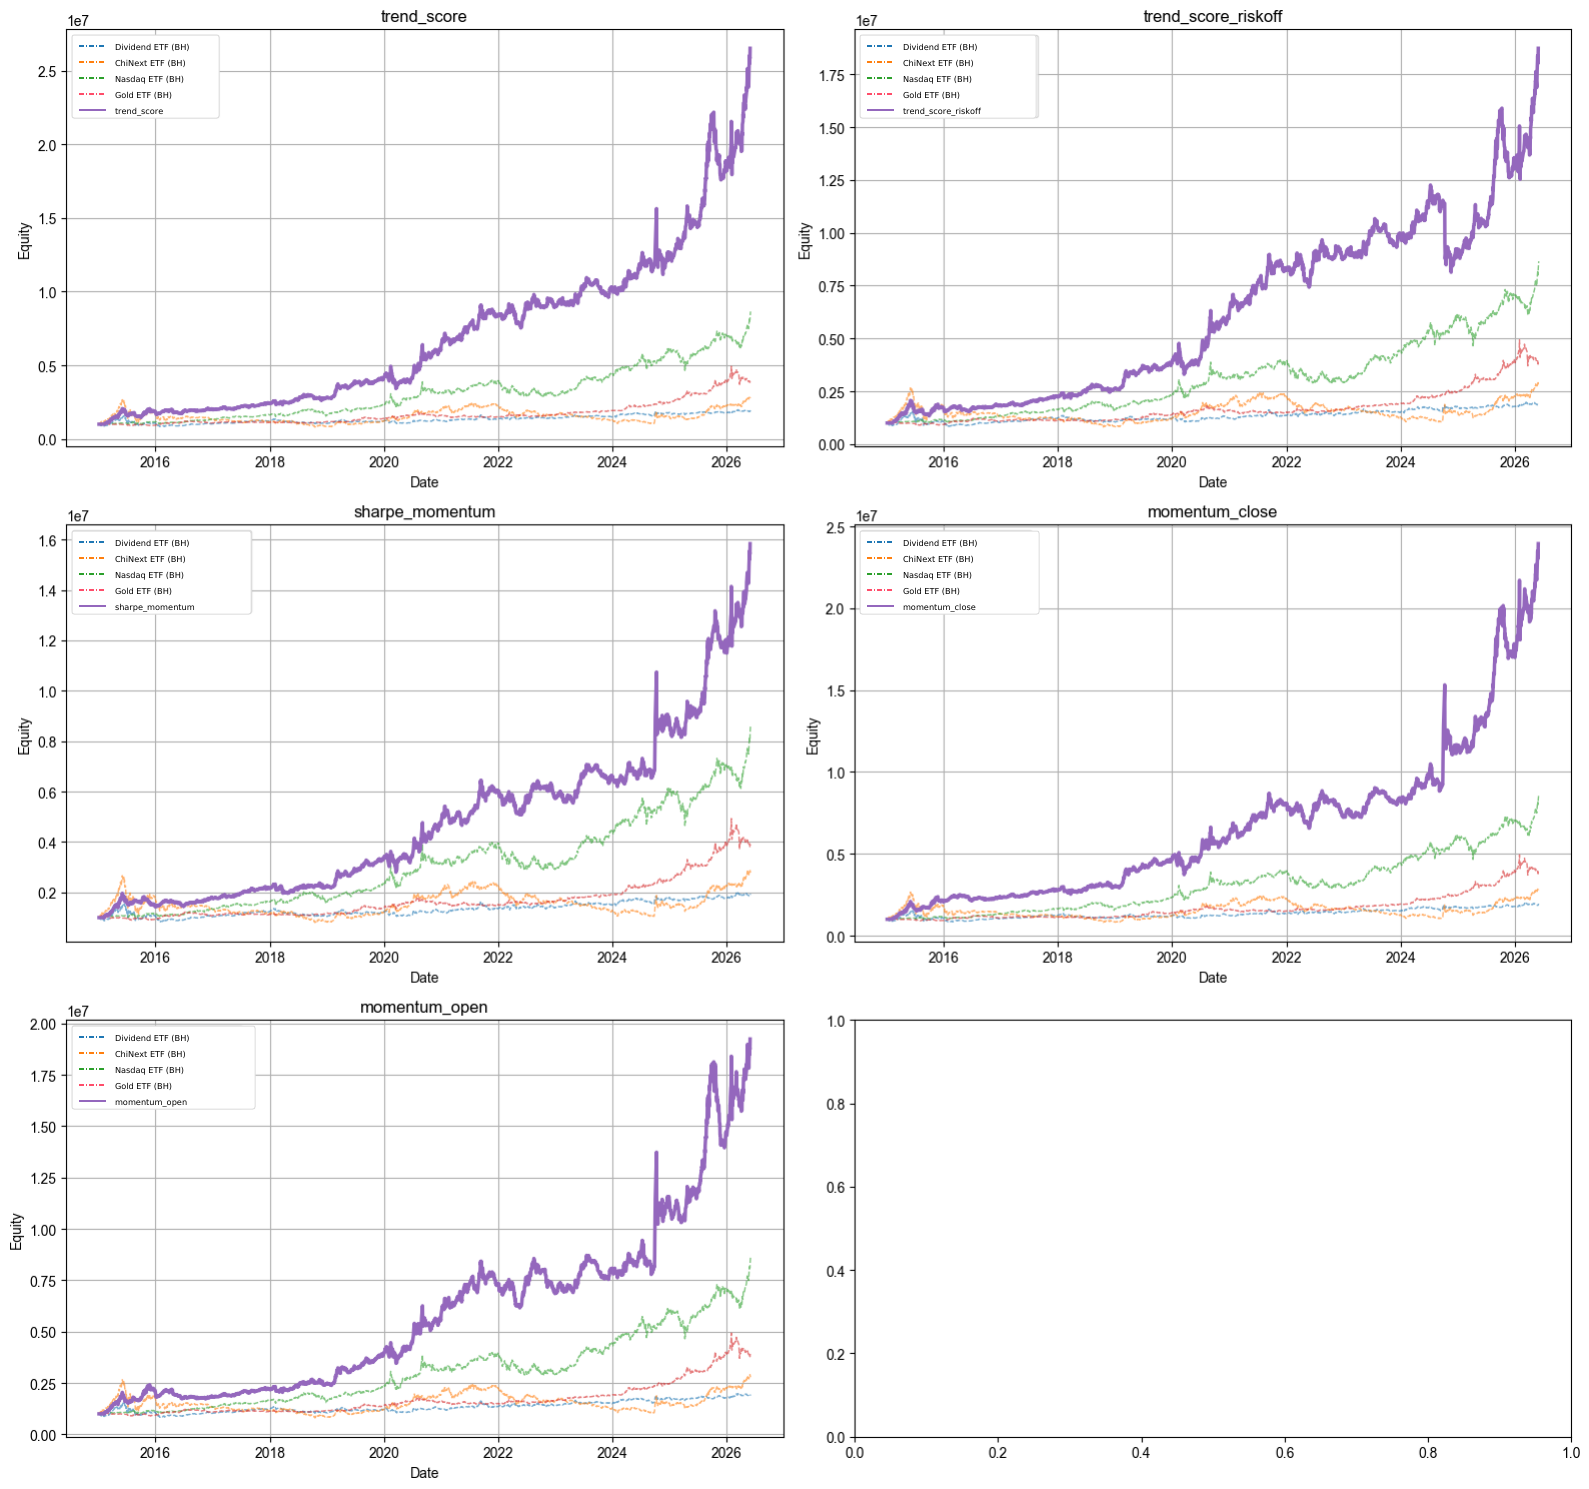


================ Metrics Table ================
                factor      CAGR  Volatility    Sharpe  Max Drawdown    Calmar
0          trend_score  0.333084    0.260910  1.274947     -0.307185  1.084310
1  trend_score_riskoff  0.293025    0.253682  1.179889     -0.355030  0.825355
2      sharpe_momentum  0.274114    0.247049  1.141035     -0.274540  0.998447
3       momentum_close  0.321154    0.264051  1.226536     -0.277680  1.156564
4        momentum_open  0.296083    0.270209  1.131000     -0.285016  1.038828


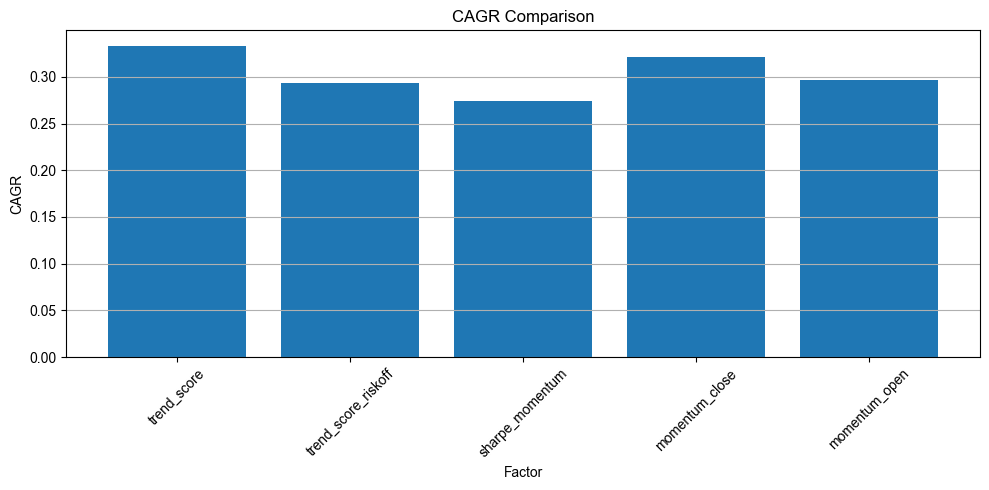


Saved to: 
/Users/wangzijie/Desktop/ETF Rotation Strategy
/Users/wangzijie/Desktop/ETF Rotation Strategy/figures


In [16]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0. Path configuration
# =========================
BASE_DIR = os.path.expanduser("~/Desktop/ETF Rotation Strategy")
FIG_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# =========================
# 1. Load data
# =========================
FILE_PATH_ETF = "data/datas/ETF日频数据/etf_panel.pkl"
df_etf = load_etf_data(FILE_PATH_ETF)

# =========================
# 2. Factor configuration
# =========================
factor_configs = {
    "trend_score": lambda: trend_score(df_etf),
    "trend_score_riskoff": lambda: trend_score_riskoff(df_etf, window=25),
    "sharpe_momentum": lambda: sharpe_momentum(df_etf, ret_window=20, vol_window=15),
    "momentum_close": lambda: momentum_close(df_etf, win_length=20),
    "momentum_open": lambda: momentum_open(df_etf, win_length=20),
    
}

# =========================
# 3. Parameters
# =========================
cash = 1_000_000

# =========================
# 4. Buy & Hold using a consistent calculation
# =========================
buyhold_curves = {}

for etf_name, df in df_etf.items():

    df = df.sort_index()
    close = df["收盘价"]

    equity = cash * close / close.iloc[0]

    buyhold_curves[etf_name] = (close.index, equity)

# =========================
# 5. subplot
# =========================
n_factor = len(factor_configs)
n_cols = 2
n_rows = math.ceil(n_factor / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

# =========================
# 6. Backtest
# =========================
results = {}
metrics_list = []

for i, (name, factor_func) in enumerate(factor_configs.items()):

    print(f"\n================ Running: {name} ================")

    factor_df = factor_func()

    portfolio = Portfolio(
        cash=cash,
        etf_cost_rate=0.00005,
        etf_slippage=0.0005,
        etf_min_cost=0.0
    )

    strategy = SingleFactorFullStrategy(factor_df=factor_df)

    engine = DelayFullEngine(
        data=df_etf,
        strategy=strategy,
        portfolio=portfolio,
        start="2015-01-01",
        end="2026-05-31"
    )

    result = engine.run()
    results[name] = result

    # =========================
    # metrics
    # =========================
    metrics = performance_metrics(result)
    metrics["factor"] = name
    metrics_list.append(metrics)

    # =========================
    # subplot
    # =========================
    ax = axes[i]

    # ---- Buy & Hold (ALL ETFs)
    for etf_name, (ts, bh_equity) in buyhold_curves.items():
        ax.plot(
            ts,
            bh_equity,
            linestyle="--",
            linewidth=1,
            alpha=0.6,
            label=f"{etf_name} BH"
        )

    # ---- Strategy
    if isinstance(result.index, pd.DatetimeIndex):
        x = result.index
    else:
        x = result["timestamp"]

    y = result["equity"]

    ax.plot(
        x,
        y,
        linewidth=2.5,
        label=f"{name} Strategy"
    )

    ax.set_title(name)
    ax.set_xlabel("Date")
    ax.set_ylabel("Equity")
    ax.grid(True)
    ax.legend(fontsize=8)

    # =========================
    # Save one chart containing all ETFs
    # =========================
    plt.figure(figsize=(10, 5))

    # Buy & Hold
    for etf_name, (ts, bh_equity) in buyhold_curves.items():
        plt.plot(
            ts,
            bh_equity,
            linestyle="--",
            linewidth=1,
            alpha=0.6,
            label=f"{etf_name} BH"
        )

    # Strategy
    plt.plot(
        x,
        y,
        linewidth=2.5,
        label=name
    )

    plt.title(name)
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.grid(True)
    plt.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=200)
    plt.close()

# =========================
# 7. Save subplots
# =========================
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/factor_vs_buyhold.png", dpi=200)
plt.show()

# =========================
# 8. metrics table
# =========================
metrics_df = pd.DataFrame(metrics_list)

cols = ["factor"] + [c for c in metrics_df.columns if c != "factor"]
metrics_df = metrics_df[cols]

print("\n================ Metrics Table ================")
print(metrics_df)

metrics_df.to_csv(f"{BASE_DIR}/metrics.csv", index=False)

# =========================
# 9. CAGR bar chart
# =========================
plt.figure(figsize=(10, 5))

plt.bar(metrics_df["factor"], metrics_df["CAGR"])

plt.xticks(rotation=45)
plt.title("CAGR Comparison")
plt.xlabel("Factor")
plt.ylabel("CAGR")
plt.grid(axis="y")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cagr_comparison.png", dpi=200)
plt.show()

print("\nSaved to: ")
print(BASE_DIR)
print(FIG_DIR)